In [1]:
# =========================
# BLOCK 1: INIT LIBRARY + SETUP PATH
# =========================

import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Sesuaikan dengan struktur notebook lama:
# notebook lama memakai ROOT = CWD.parent.parent
CWD = Path.cwd().resolve()
ROOT = CWD.parent.parent

PREP_DIR = ROOT / "output" / "preprocessing"
V1_DIR = ROOT / "output" / "V1" / "baseline_official"
OUT_DIR = ROOT / "output" / "V2" / "baseline_official" / "loss_curve_diagnostics"
FIG_DIR = OUT_DIR / "figures"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("CWD     :", CWD)
print("ROOT    :", ROOT)
print("PREP_DIR:", PREP_DIR)
print("V1_DIR  :", V1_DIR)
print("OUT_DIR :", OUT_DIR)

assert PREP_DIR.exists(), f"PREP_DIR tidak ditemukan: {PREP_DIR}"
assert V1_DIR.exists(), f"V1_DIR tidak ditemukan: {V1_DIR}"

CWD     : E:\AnotherPunyaQQ\tugas-akhir-qq\code\V2
ROOT    : E:\AnotherPunyaQQ\tugas-akhir-qq
PREP_DIR: E:\AnotherPunyaQQ\tugas-akhir-qq\output\preprocessing
V1_DIR  : E:\AnotherPunyaQQ\tugas-akhir-qq\output\V1\baseline_official
OUT_DIR : E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_official\loss_curve_diagnostics


In [2]:
# =========================
# BLOCK 2: LOAD OFFICIAL METADATA + EXCLUDE VAD DROP
# =========================

train_path = PREP_DIR / "meta_train_official.csv"
val_path   = PREP_DIR / "meta_val_official.csv"
test_path  = PREP_DIR / "meta_test_official.csv"

VAD_DROP_PATH = PREP_DIR / "vad" / "vad_drop.csv"

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

print("[Before VAD drop]")
print("Train:", df_train.shape)
print("Val  :", df_val.shape)
print("Test :", df_test.shape)

vad_drop = pd.read_csv(VAD_DROP_PATH)
drop_ids = set(vad_drop["clip_id"].astype(str))

def exclude_vad_drop(df, split_name):
    before = len(df)
    df = df.copy()
    df["clip_id"] = df["clip_id"].astype(str)
    df = df[~df["clip_id"].isin(drop_ids)].reset_index(drop=True)
    after = len(df)
    print(f"{split_name}: excluded={before-after}, final={after}")
    return df

df_train = exclude_vad_drop(df_train, "train")
df_val   = exclude_vad_drop(df_val, "validation")
df_test  = exclude_vad_drop(df_test, "test")

print("\n[After VAD drop]")
print("Train:", df_train.shape)
print("Val  :", df_val.shape)
print("Test :", df_test.shape)
print("Total:", len(df_train) + len(df_val) + len(df_test))

[Before VAD drop]
Train: (6000, 13)
Val  : (2000, 13)
Test : (2000, 13)
train: excluded=12, final=5988
validation: excluded=6, final=1994
test: excluded=8, final=1992

[After VAD drop]
Train: (5988, 13)
Val  : (1994, 13)
Test : (1992, 13)
Total: 9974


In [3]:
# =========================
# BLOCK 3: DETECT / DEFINE BIG FIVE LABEL COLUMNS
# =========================

# Lebih aman pakai urutan eksplisit sesuai TA kamu
LABEL_COLS = [
    "extraversion",
    "neuroticism",
    "agreeableness",
    "conscientiousness",
    "openness",
]

missing_labels = [c for c in LABEL_COLS if c not in df_train.columns]
if missing_labels:
    raise ValueError(f"Kolom label tidak ditemukan: {missing_labels}")

y_train = df_train[LABEL_COLS].to_numpy(dtype=np.float32)
y_val   = df_val[LABEL_COLS].to_numpy(dtype=np.float32)
y_test  = df_test[LABEL_COLS].to_numpy(dtype=np.float32)

print("LABEL_COLS:", LABEL_COLS)
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

LABEL_COLS: ['extraversion', 'neuroticism', 'agreeableness', 'conscientiousness', 'openness']
y_train: (5988, 5)
y_val  : (1994, 5)
y_test : (1992, 5)


In [4]:
# =========================
# BLOCK 4: HELPER LOAD SSL EMBEDDING FROM V1
# =========================

def load_ssl_official_pool(backbone_key: str):
    """
    Load embedding SSL dari output V1 baseline_official.
    File yang dipakai:
    - train_emb.npy, val_emb.npy, test_emb.npy
    - train_clip_id.csv, val_clip_id.csv, test_clip_id.csv
    """
    emb_dir = V1_DIR / "embeddings" / backbone_key
    assert emb_dir.exists(), f"Folder embedding tidak ditemukan: {emb_dir}"

    X_pool = {}
    ids_pool = {}

    for split in ["train", "val", "test"]:
        x_path = emb_dir / f"{split}_emb.npy"
        id_path = emb_dir / f"{split}_clip_id.csv"

        assert x_path.exists(), f"Tidak ditemukan: {x_path}"
        assert id_path.exists(), f"Tidak ditemukan: {id_path}"

        X_pool[split] = np.load(x_path, mmap_mode="r")
        ids_pool[split] = pd.read_csv(id_path)["clip_id"].astype(str).tolist()

        print(f"[{backbone_key}] {split}: X={X_pool[split].shape}, ids={len(ids_pool[split])}")

    id2loc = {}
    for split in ["train", "val", "test"]:
        for i, cid in enumerate(ids_pool[split]):
            id2loc[cid] = (split, i)

    hidden_size = X_pool["train"].shape[1]

    def align_to_df(df_split, split_name):
        target_ids = df_split["clip_id"].astype(str).tolist()
        X = np.zeros((len(target_ids), hidden_size), dtype=np.float32)

        missing = []
        for j, cid in enumerate(target_ids):
            loc = id2loc.get(cid)
            if loc is None:
                missing.append(cid)
            else:
                source_split, source_idx = loc
                X[j] = X_pool[source_split][source_idx]

        if missing:
            raise ValueError(
                f"[{backbone_key}] Missing embedding pada {split_name}: "
                f"{len(missing)} contoh: {missing[:5]}"
            )

        print(f"[{backbone_key}] aligned {split_name}: {X.shape}")
        return X

    X_train = align_to_df(df_train, "train")
    X_val   = align_to_df(df_val, "validation")
    X_test  = align_to_df(df_test, "test")

    return X_train, X_val, X_test

In [5]:
# =========================
# BLOCK 5: HELPER LOAD EGEMAPS FROM V1
# =========================

def load_egemaps_official_pool():
    """
    Load eGeMAPS dari output V1 baseline_official.
    File yang dipakai:
    - train_egemaps.csv
    - val_egemaps.csv
    - test_egemaps.csv
    """
    eg_dir = V1_DIR / "egemaps"
    assert eg_dir.exists(), f"Folder eGeMAPS tidak ditemukan: {eg_dir}"

    eg_train = pd.read_csv(eg_dir / "train_egemaps.csv")
    eg_val   = pd.read_csv(eg_dir / "val_egemaps.csv")
    eg_test  = pd.read_csv(eg_dir / "test_egemaps.csv")

    eg_pool = pd.concat([eg_train, eg_val, eg_test], ignore_index=True)
    eg_pool["clip_id"] = eg_pool["clip_id"].astype(str)
    eg_pool = eg_pool.drop_duplicates(subset=["clip_id"], keep="first")
    eg_pool = eg_pool.set_index("clip_id")

    feature_cols = [c for c in eg_pool.columns if c != "clip_id"]

    print("eGeMAPS pool:", eg_pool.shape)
    print("Jumlah fitur eGeMAPS:", len(feature_cols))

    def align_to_df(df_split, split_name):
        target_ids = df_split["clip_id"].astype(str).tolist()
        missing = [cid for cid in target_ids if cid not in eg_pool.index]

        if missing:
            raise ValueError(
                f"[egemaps] Missing eGeMAPS pada {split_name}: "
                f"{len(missing)} contoh: {missing[:5]}"
            )

        X = eg_pool.loc[target_ids, feature_cols].to_numpy(dtype=np.float32)
        print(f"[egemaps] aligned {split_name}: {X.shape}")
        return X

    X_train = align_to_df(df_train, "train")
    X_val   = align_to_df(df_val, "validation")
    X_test  = align_to_df(df_test, "test")

    return X_train, X_val, X_test

In [6]:
# =========================
# BLOCK 6: RIDGE ALPHA SWEEP + TRAIN/VALIDATION ERROR
# =========================

ALPHAS = np.array([
    1e-3, 3e-3,
    1e-2, 3e-2,
    1e-1, 3e-1,
    1, 3,
    10, 30,
    100, 300,
    1_000, 3_000,
    10_000, 30_000,
    100_000
], dtype=float)


def evaluate_metrics(y_true, y_pred):
    mae_raw = mean_absolute_error(y_true, y_pred, multioutput="raw_values")
    rmse_raw = np.sqrt(mean_squared_error(y_true, y_pred, multioutput="raw_values"))
    r2_raw = r2_score(y_true, y_pred, multioutput="raw_values")

    return {
        "MAE_mean": float(mae_raw.mean()),
        "RMSE_mean": float(rmse_raw.mean()),
        "R2_mean": float(r2_raw.mean()),
        "Acc_mean": float(1.0 - mae_raw.mean()),
    }


def run_ridge_error_curve(method_name, X_train, X_val, X_test=None):
    """
    method_name: "hubert", "wav2vec2", "wavlm", atau "egemaps"
    X_train, X_val: fitur yang sudah align dengan df_train dan df_val

    Catatan:
    Ridge Regression tidak menghasilkan loss per epoch.
    Oleh karena itu, kurva train-validation ditampilkan terhadap variasi alpha.
    Galat utama yang dipakai adalah MAE agar konsisten dengan metrik utama TA.
    """

    print("\n" + "=" * 80)
    print(f"RUN RIDGE TRAIN-VALIDATION ERROR CURVE: {method_name}")
    print("=" * 80)

    method_out_dir = OUT_DIR / method_name
    method_fig_dir = method_out_dir / "figures"
    method_out_dir.mkdir(parents=True, exist_ok=True)
    method_fig_dir.mkdir(parents=True, exist_ok=True)

    # StandardScaler fit hanya di train agar tidak terjadi leakage
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)

    rows = []

    best_alpha_by_val_mae = None
    best_val_mae = np.inf

    for alpha in ALPHAS:
        ridge = Ridge(alpha=float(alpha))
        model = MultiOutputRegressor(ridge)
        model.fit(X_train_s, y_train)

        pred_train = model.predict(X_train_s)
        pred_val   = model.predict(X_val_s)

        train_metrics = evaluate_metrics(y_train, pred_train)
        val_metrics   = evaluate_metrics(y_val, pred_val)

        coef_norms = [np.linalg.norm(est.coef_) for est in model.estimators_]

        row = {
            "method": method_name,
            "alpha": float(alpha),

            "train_MAE": train_metrics["MAE_mean"],
            "val_MAE": val_metrics["MAE_mean"],

            "train_RMSE": train_metrics["RMSE_mean"],
            "val_RMSE": val_metrics["RMSE_mean"],

            "train_R2": train_metrics["R2_mean"],
            "val_R2": val_metrics["R2_mean"],

            "train_Acc(1-MAE)": train_metrics["Acc_mean"],
            "val_Acc(1-MAE)": val_metrics["Acc_mean"],

            "mean_coef_norm": float(np.mean(coef_norms)),
        }

        rows.append(row)

        print(
            f"alpha={alpha:>9.4g} | "
            f"train MAE={row['train_MAE']:.6f} | "
            f"val MAE={row['val_MAE']:.6f} | "
            f"train RMSE={row['train_RMSE']:.6f} | "
            f"val RMSE={row['val_RMSE']:.6f} | "
            f"val R2={row['val_R2']:.6f} | "
            f"val Acc={row['val_Acc(1-MAE)']:.6f}"
        )

        # Alpha efektif mengikuti eksperimen baseline utama: validation MAE
        if row["val_MAE"] < best_val_mae:
            best_val_mae = row["val_MAE"]
            best_alpha_by_val_mae = float(alpha)

    error_df = pd.DataFrame(rows).sort_values("alpha").reset_index(drop=True)

    error_csv_path = method_out_dir / f"{method_name}_ridge_train_val_error_alpha_sweep.csv"
    error_df.to_csv(error_csv_path, index=False)

    print("\nBest alpha by validation MAE:", best_alpha_by_val_mae)
    print("Best validation MAE:", best_val_mae)
    print("Saved CSV:", error_csv_path)

    return error_df, best_alpha_by_val_mae, method_out_dir, method_fig_dir

In [7]:
# =========================
# BLOCK 7: PLOT TRAIN VS VALIDATION MAE AGAINST ALPHA
# =========================

def plot_mae_curve(error_df, method_name, selected_alpha, fig_dir):
    plt.figure(figsize=(10, 6))

    plt.plot(
        error_df["alpha"],
        error_df["train_MAE"],
        marker="o",
        label="Train MAE"
    )

    plt.plot(
        error_df["alpha"],
        error_df["val_MAE"],
        marker="o",
        label="Validation MAE"
    )

    plt.axvline(
        selected_alpha,
        linestyle="--",
        linewidth=1.5,
        label=f"Selected alpha={selected_alpha:g}"
    )

    plt.xscale("log")
    plt.xlabel("Alpha (log scale)")
    plt.ylabel("MAE")
    plt.title(f"Train vs Validation MAE Ridge Regression ({method_name})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    save_path = fig_dir / f"{method_name}_ridge_train_val_mae_vs_alpha.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved figure:", save_path)

In [8]:
# =========================
# BLOCK 8: PLOT TRAIN VS VALIDATION MAE AT SELECTED ALPHA
# =========================

def plot_selected_alpha_bar(error_df, method_name, selected_alpha, fig_dir):
    selected_row = error_df[np.isclose(error_df["alpha"], selected_alpha)].iloc[0]

    labels = ["Train MAE", "Validation MAE"]
    values = [
        selected_row["train_MAE"],
        selected_row["val_MAE"],
    ]

    plt.figure(figsize=(7, 5))
    plt.bar(labels, values)
    plt.ylabel("MAE")
    plt.title(f"Train vs Validation MAE at Selected Alpha={selected_alpha:g} ({method_name})")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    save_path = fig_dir / f"{method_name}_ridge_train_val_mae_selected_alpha.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved figure:", save_path)

    summary = {
        "method": method_name,
        "selected_alpha": float(selected_alpha),

        "train_MAE": float(selected_row["train_MAE"]),
        "val_MAE": float(selected_row["val_MAE"]),

        "train_RMSE": float(selected_row["train_RMSE"]),
        "val_RMSE": float(selected_row["val_RMSE"]),

        "train_R2": float(selected_row["train_R2"]),
        "val_R2": float(selected_row["val_R2"]),

        "train_Acc(1-MAE)": float(selected_row["train_Acc(1-MAE)"]),
        "val_Acc(1-MAE)": float(selected_row["val_Acc(1-MAE)"]),
    }

    summary_path = fig_dir.parent / f"{method_name}_selected_alpha_error_summary.json"
    summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

    print("Saved selected alpha summary:", summary_path)
    return summary



####################################################################################################
PROCESS METHOD: hubert
####################################################################################################
[hubert] train: X=(5988, 768), ids=5988
[hubert] val: X=(1994, 768), ids=1994
[hubert] test: X=(1992, 768), ids=1992
[hubert] aligned train: (5988, 768)
[hubert] aligned validation: (1994, 768)
[hubert] aligned test: (1992, 768)

RUN RIDGE TRAIN-VALIDATION ERROR CURVE: hubert
alpha=    0.001 | train MAE=0.089028 | val MAE=0.099667 | train RMSE=0.111742 | val RMSE=0.125557 | val R2=0.240881 | val Acc=0.900333
alpha=    0.003 | train MAE=0.089028 | val MAE=0.099667 | train RMSE=0.111742 | val RMSE=0.125557 | val R2=0.240882 | val Acc=0.900333
alpha=     0.01 | train MAE=0.089028 | val MAE=0.099666 | train RMSE=0.111742 | val RMSE=0.125556 | val R2=0.240896 | val Acc=0.900334
alpha=     0.03 | train MAE=0.089028 | val MAE=0.099664 | train RMSE=0.111742 | val RMSE=0.

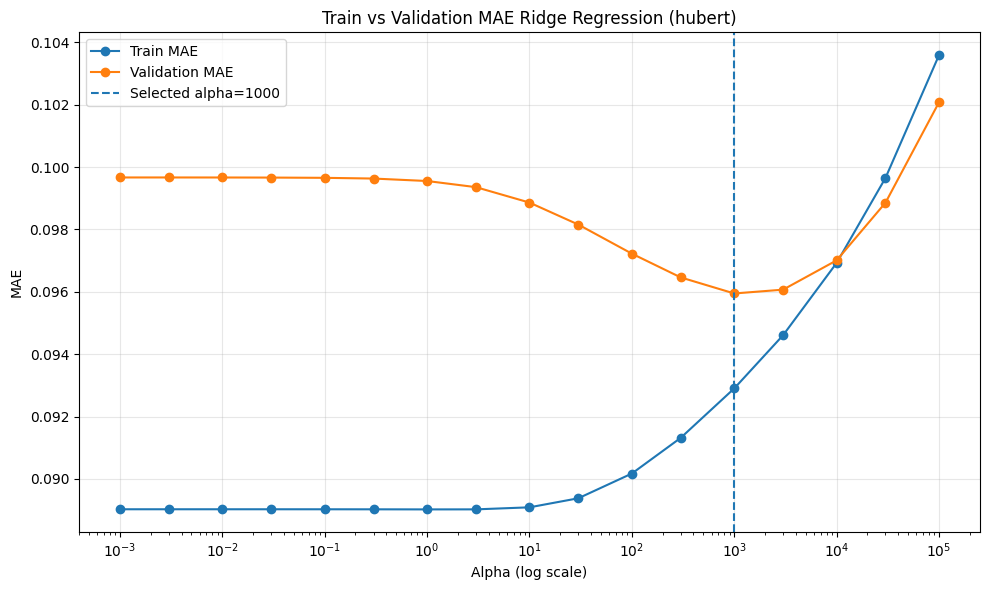

Saved figure: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_official\loss_curve_diagnostics\hubert\figures\hubert_ridge_train_val_mae_vs_alpha.png


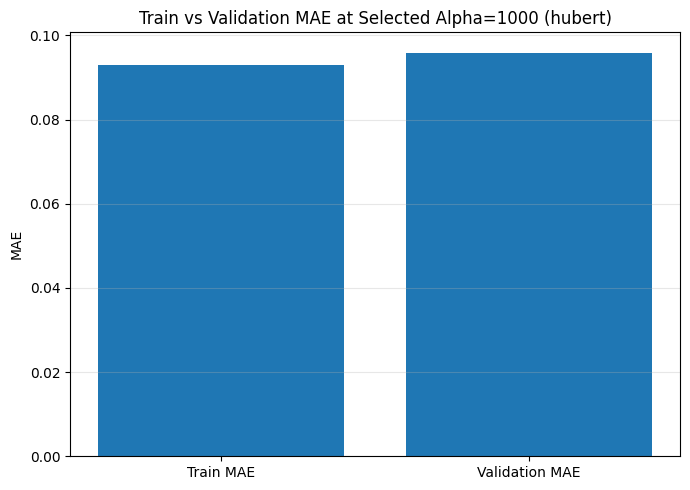

Saved figure: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_official\loss_curve_diagnostics\hubert\figures\hubert_ridge_train_val_mae_selected_alpha.png
Saved selected alpha summary: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_official\loss_curve_diagnostics\hubert\hubert_selected_alpha_error_summary.json


####################################################################################################
PROCESS METHOD: wav2vec2
####################################################################################################
[wav2vec2] train: X=(5988, 768), ids=5988
[wav2vec2] val: X=(1994, 768), ids=1994
[wav2vec2] test: X=(1992, 768), ids=1992
[wav2vec2] aligned train: (5988, 768)
[wav2vec2] aligned validation: (1994, 768)
[wav2vec2] aligned test: (1992, 768)

RUN RIDGE TRAIN-VALIDATION ERROR CURVE: wav2vec2
alpha=    0.001 | train MAE=0.089233 | val MAE=0.100324 | train RMSE=0.112113 | val RMSE=0.126305 | val R2=0.232204 | val Acc=0.899676
alpha=    0.003 | train 

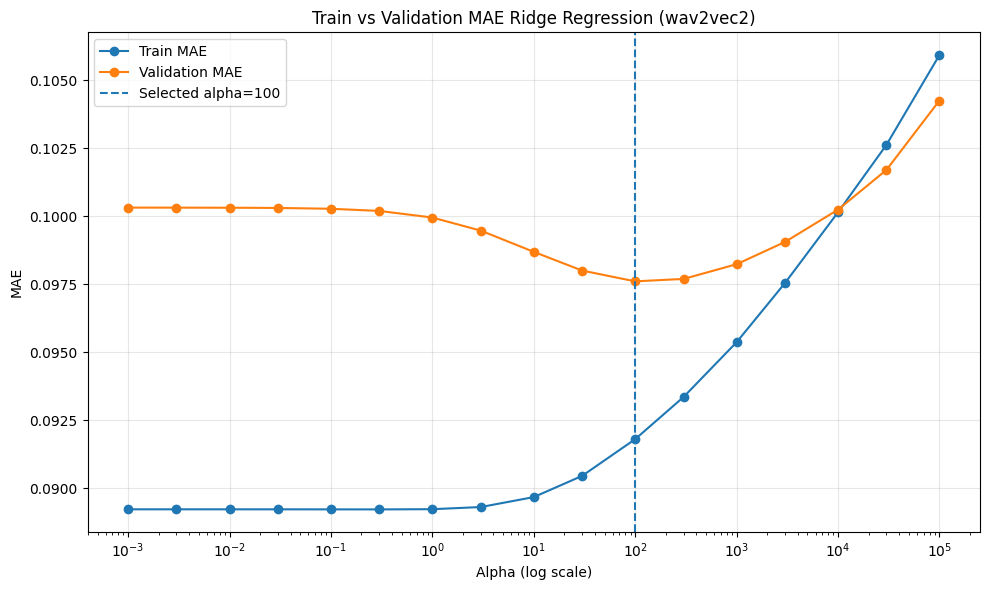

Saved figure: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_official\loss_curve_diagnostics\wav2vec2\figures\wav2vec2_ridge_train_val_mae_vs_alpha.png


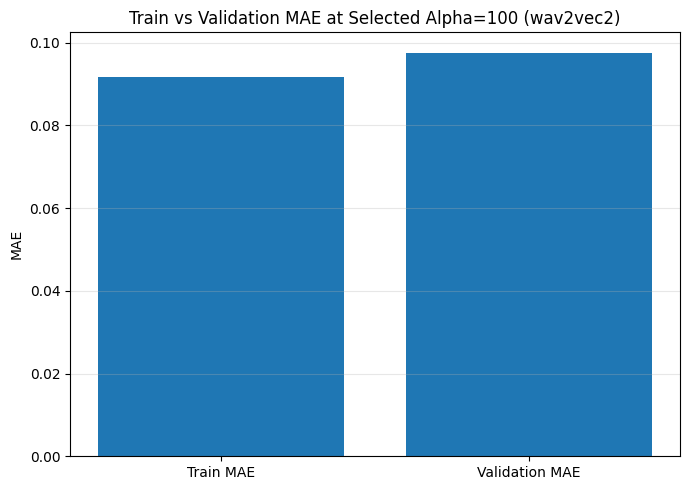

Saved figure: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_official\loss_curve_diagnostics\wav2vec2\figures\wav2vec2_ridge_train_val_mae_selected_alpha.png
Saved selected alpha summary: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_official\loss_curve_diagnostics\wav2vec2\wav2vec2_selected_alpha_error_summary.json


####################################################################################################
PROCESS METHOD: wavlm
####################################################################################################
[wavlm] train: X=(5988, 768), ids=5988
[wavlm] val: X=(1994, 768), ids=1994
[wavlm] test: X=(1992, 768), ids=1992
[wavlm] aligned train: (5988, 768)
[wavlm] aligned validation: (1994, 768)
[wavlm] aligned test: (1992, 768)

RUN RIDGE TRAIN-VALIDATION ERROR CURVE: wavlm
alpha=    0.001 | train MAE=0.088089 | val MAE=0.098106 | train RMSE=0.110866 | val RMSE=0.123421 | val R2=0.264315 | val Acc=0.901894
alpha=    0.003 | train MAE=0.088089 | v

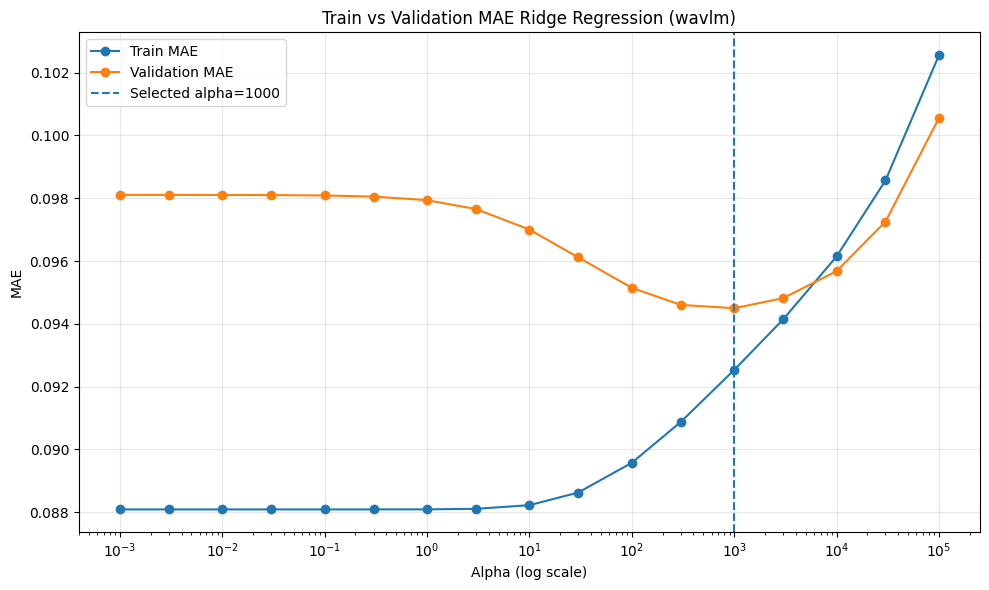

Saved figure: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_official\loss_curve_diagnostics\wavlm\figures\wavlm_ridge_train_val_mae_vs_alpha.png


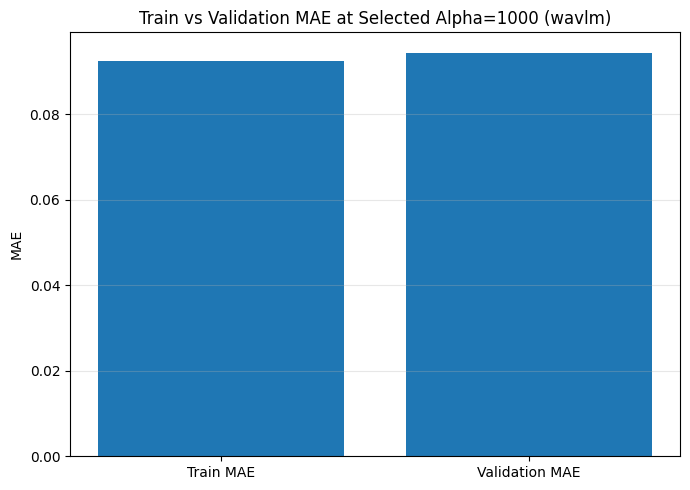

Saved figure: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_official\loss_curve_diagnostics\wavlm\figures\wavlm_ridge_train_val_mae_selected_alpha.png
Saved selected alpha summary: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_official\loss_curve_diagnostics\wavlm\wavlm_selected_alpha_error_summary.json


####################################################################################################
PROCESS METHOD: egemaps
####################################################################################################
eGeMAPS pool: (9974, 88)
Jumlah fitur eGeMAPS: 88
[egemaps] aligned train: (5988, 88)
[egemaps] aligned validation: (1994, 88)
[egemaps] aligned test: (1992, 88)

RUN RIDGE TRAIN-VALIDATION ERROR CURVE: egemaps
alpha=    0.001 | train MAE=0.103446 | val MAE=0.103516 | train RMSE=0.130045 | val RMSE=0.130772 | val R2=0.180362 | val Acc=0.896484
alpha=    0.003 | train MAE=0.103446 | val MAE=0.103515 | train RMSE=0.130045 | val RMSE=0.130771 | val R2=0.

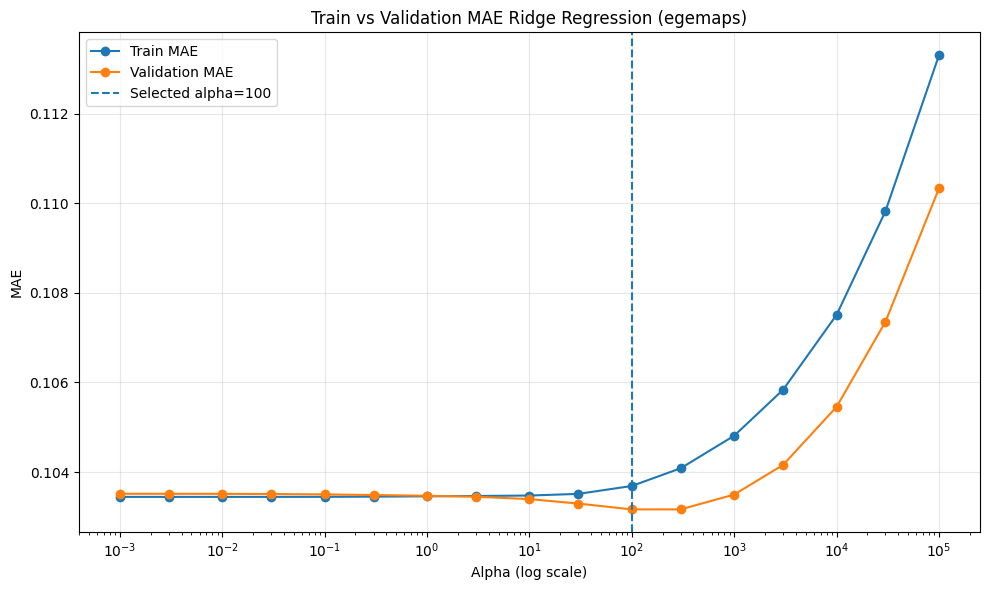

Saved figure: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_official\loss_curve_diagnostics\egemaps\figures\egemaps_ridge_train_val_mae_vs_alpha.png


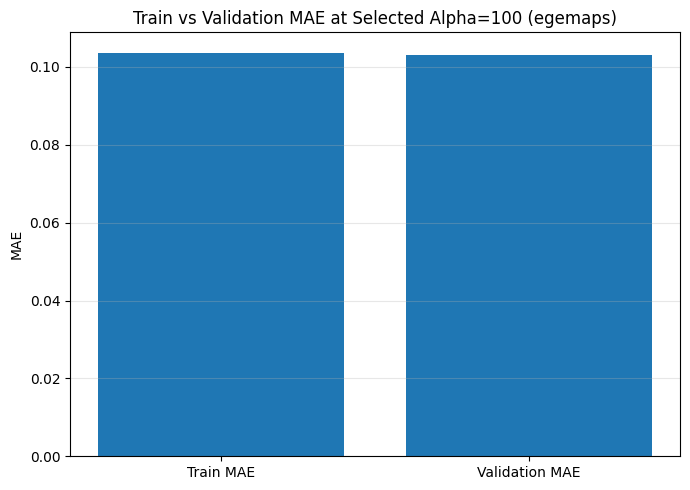

Saved figure: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_official\loss_curve_diagnostics\egemaps\figures\egemaps_ridge_train_val_mae_selected_alpha.png
Saved selected alpha summary: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_official\loss_curve_diagnostics\egemaps\egemaps_selected_alpha_error_summary.json

DONE.
Combined error CSV: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_official\loss_curve_diagnostics\combined_ridge_train_val_error_alpha_sweep.csv
Selected alpha summary: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_official\loss_curve_diagnostics\selected_alpha_error_summary_all_methods.csv


,method,selected_alpha,train_MAE,val_MAE,train_RMSE,val_RMSE,train_R2,val_R2,train_Acc(1-MAE),val_Acc(1-MAE)
0,hubert,1000.0,0.092903,0.095947,0.117067,0.120795,0.378354,0.297344,0.907097,0.904053
1,wav2vec2,100.0,0.091811,0.097613,0.115532,0.122423,0.394681,0.278640,0.908189,0.902387
2,wavlm,1000.0,0.092533,0.094497,0.116556,0.118895,0.383785,0.318673,0.907467,0.905503
3,egemaps,100.0,0.103690,0.103167,0.130387,0.130353,0.231014,0.185565,0.896310,0.896833


In [9]:
# =========================
# BLOCK 9: RUN RIDGE ERROR CURVE DIAGNOSTICS FOR ALL METHODS
# =========================

METHODS_TO_RUN = [
    "hubert",
    "wav2vec2",
    "wavlm",
    "egemaps",
]

all_error_dfs = []
selected_alpha_summaries = []

for method in METHODS_TO_RUN:
    print("\n\n" + "#" * 100)
    print(f"PROCESS METHOD: {method}")
    print("#" * 100)

    if method in ["hubert", "wav2vec2", "wavlm"]:
        X_train, X_val, X_test = load_ssl_official_pool(method)
    elif method == "egemaps":
        X_train, X_val, X_test = load_egemaps_official_pool()
    else:
        raise ValueError(f"Unknown method: {method}")

    error_df, best_alpha_by_val_mae, method_out_dir, method_fig_dir = run_ridge_error_curve(
        method_name=method,
        X_train=X_train,
        X_val=X_val,
        X_test=X_test,
    )

    # Alpha efektif sesuai eksperimen baseline:
    # alpha dipilih berdasarkan validation MAE.
    selected_alpha = best_alpha_by_val_mae

    plot_mae_curve(
        error_df=error_df,
        method_name=method,
        selected_alpha=selected_alpha,
        fig_dir=method_fig_dir,
    )

    selected_summary = plot_selected_alpha_bar(
        error_df=error_df,
        method_name=method,
        selected_alpha=selected_alpha,
        fig_dir=method_fig_dir,
    )

    all_error_dfs.append(error_df)
    selected_alpha_summaries.append(selected_summary)

combined_error_df = pd.concat(all_error_dfs, ignore_index=True)
combined_error_path = OUT_DIR / "combined_ridge_train_val_error_alpha_sweep.csv"
combined_error_df.to_csv(combined_error_path, index=False)

selected_summary_df = pd.DataFrame(selected_alpha_summaries)
selected_summary_path = OUT_DIR / "selected_alpha_error_summary_all_methods.csv"
selected_summary_df.to_csv(selected_summary_path, index=False)

print("\nDONE.")
print("Combined error CSV:", combined_error_path)
print("Selected alpha summary:", selected_summary_path)

display(selected_summary_df)

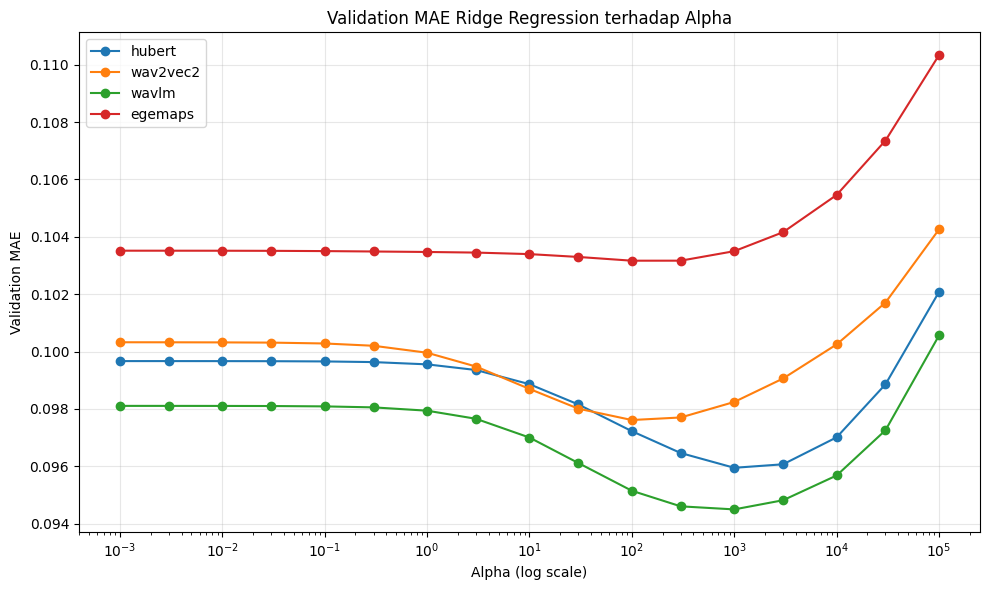

Saved figure: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_official\loss_curve_diagnostics\figures\combined_validation_mae_vs_alpha.png


In [10]:
# =========================
# BLOCK 10: COMBINED VALIDATION MAE CURVE
# =========================

plt.figure(figsize=(10, 6))

for method in METHODS_TO_RUN:
    d = combined_error_df[combined_error_df["method"] == method].sort_values("alpha")
    plt.plot(
        d["alpha"],
        d["val_MAE"],
        marker="o",
        label=method
    )

plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Validation MAE")
plt.title("Validation MAE Ridge Regression terhadap Alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

save_path = FIG_DIR / "combined_validation_mae_vs_alpha.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", save_path)

In [11]:
# =========================
# BLOCK 11: AUTO SUMMARY FOR THESIS TEXT
# =========================

summary_lines = []

summary_lines.append("Ringkasan diagnostic train-validation error Ridge Regression")
summary_lines.append("=" * 70)
summary_lines.append("")
summary_lines.append(
    "Karena Ridge Regression tidak dilatih secara epoch-based seperti neural network, "
    "kurva loss per epoch tidak tersedia. Sebagai pengganti, analisis train-validation "
    "ditampilkan terhadap variasi nilai alpha. Setiap titik pada kurva merepresentasikan "
    "satu model Ridge yang dilatih dengan nilai alpha tertentu."
)
summary_lines.append("")
summary_lines.append(
    "Galat yang digunakan pada kurva utama adalah MAE, karena MAE merupakan metrik evaluasi "
    "utama pada penelitian ini dan juga digunakan sebagai dasar pemilihan alpha terbaik pada "
    "validation set. Dengan demikian, kurva ini digunakan untuk melihat pengaruh regularisasi "
    "terhadap performa train dan validation, bukan sebagai riwayat loss internal per epoch."
)
summary_lines.append("")

for _, row in selected_summary_df.iterrows():
    summary_lines.append(
        f"- {row['method']}: selected alpha={row['selected_alpha']:g}, "
        f"train MAE={row['train_MAE']:.6f}, "
        f"validation MAE={row['val_MAE']:.6f}, "
        f"train RMSE={row['train_RMSE']:.6f}, "
        f"validation RMSE={row['val_RMSE']:.6f}, "
        f"train R2={row['train_R2']:.6f}, "
        f"validation R2={row['val_R2']:.6f}, "
        f"train Acc(1-MAE)={row['train_Acc(1-MAE)']:.6f}, "
        f"validation Acc(1-MAE)={row['val_Acc(1-MAE)']:.6f}."
    )

summary_text = "\n".join(summary_lines)

summary_path = OUT_DIR / "ridge_error_curve_diagnostic_summary.txt"
summary_path.write_text(summary_text, encoding="utf-8")

print(summary_text)
print("\nSaved summary:", summary_path)

Ringkasan diagnostic train-validation error Ridge Regression

Karena Ridge Regression tidak dilatih secara epoch-based seperti neural network, kurva loss per epoch tidak tersedia. Sebagai pengganti, analisis train-validation ditampilkan terhadap variasi nilai alpha. Setiap titik pada kurva merepresentasikan satu model Ridge yang dilatih dengan nilai alpha tertentu.

Galat yang digunakan pada kurva utama adalah MAE, karena MAE merupakan metrik evaluasi utama pada penelitian ini dan juga digunakan sebagai dasar pemilihan alpha terbaik pada validation set. Dengan demikian, kurva ini digunakan untuk melihat pengaruh regularisasi terhadap performa train dan validation, bukan sebagai riwayat loss internal per epoch.

- hubert: selected alpha=1000, train MAE=0.092903, validation MAE=0.095947, train RMSE=0.117067, validation RMSE=0.120795, train R2=0.378354, validation R2=0.297344, train Acc(1-MAE)=0.907097, validation Acc(1-MAE)=0.904053.
- wav2vec2: selected alpha=100, train MAE=0.091811, va